In [1]:
# Charger les données déjà nettoyées
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")

trips = pd.read_parquet(PROCESSED / "trips_clean_2024.parquet")

print(f"Shape: {trips.shape}")
trips.head()

Shape: (12958560, 13)


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,start_time,end_time,duration_min
0,Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.510254,-73.556778,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502941,-73.560638,1704230756167,1.704231e+12,2024-01-02 21:25:56.167,2024-01-02 21:31:46.232,5.834417
1,Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.506313,-73.559669,de Maisonneuve / Aylmer (est),Ville-Marie,45.505386,-73.570435,1704232888826,1.704233e+12,2024-01-02 22:01:28.826,2024-01-02 22:08:23.502,6.911267
2,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.527195,-73.564522,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549023,-73.591980,1704238154678,1.704239e+12,2024-01-02 23:29:14.678,2024-01-02 23:49:19.500,20.080367
3,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531025,-73.598625,Roy / St-André,Le Plateau-Mont-Royal,45.521564,-73.570366,1704232695740,1.704233e+12,2024-01-02 21:58:15.740,2024-01-02 22:08:49.014,10.554567
4,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.531025,-73.598625,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549023,-73.591980,1704243796167,1.704244e+12,2024-01-03 01:03:16.167,2024-01-03 01:14:44.511,11.472400


In [3]:
# Petit réglage esthétique pour des graphiques plus lisibles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
# Extraire l'heure de départ
trips["hour"] = trips["start_time"].dt.hour

hourly_counts = trips["hour"].value_counts().sort_index()

fig, ax = plt.subplots()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color="steelblue", ax=ax)
ax.set_title("Volume de trajets BIXI par heure de la journée — 2024")
ax.set_xlabel("Heure")
ax.set_ylabel("Nombre de trajets")
plt.tight_layout()
plt.show()

In [5]:
# Les timestamps sont en UTC — les convertir en heure de Montréal (gère automatiquement l'heure d'été/hiver)
trips["start_time"] = trips["start_time"].dt.tz_localize("UTC").dt.tz_convert("America/Montreal")
trips["end_time"] = trips["end_time"].dt.tz_localize("UTC").dt.tz_convert("America/Montreal")

# Recalculer l'heure de départ locale
trips["hour"] = trips["start_time"].dt.hour

trips[["start_time", "hour"]].head()

,start_time,hour
0,2024-01-02 16:25:56.167000-05:00,16
1,2024-01-02 17:01:28.826000-05:00,17
2,2024-01-02 18:29:14.678000-05:00,18
3,2024-01-02 16:58:15.740000-05:00,16
4,2024-01-02 20:03:16.167000-05:00,20


**Technical note**: source timestamps are in UTC. Converting to the Montreal timezone
(`America/Montreal`) was necessary to reveal the true local hourly pattern — without this
conversion, the chart showed an artificial evening peak instead of the expected commute
pattern (8am / 5pm).


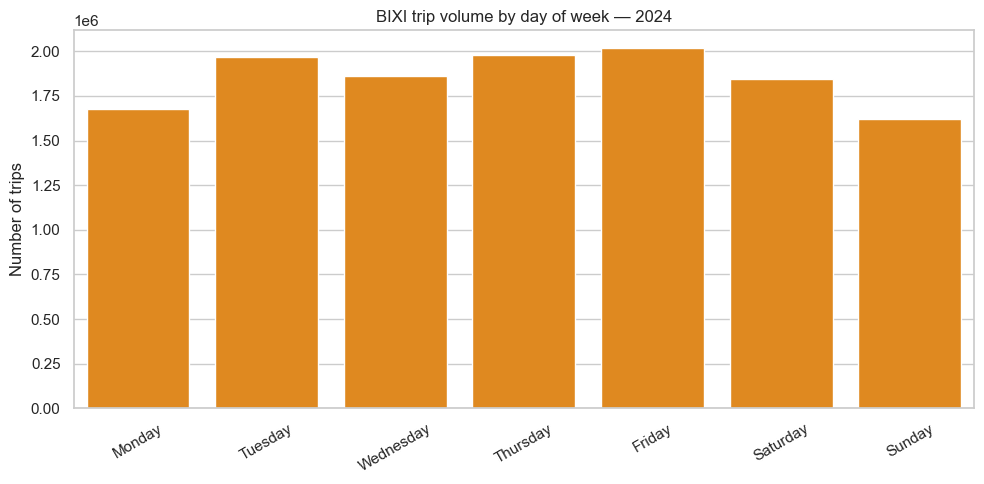

In [7]:
# Extract day of week (Monday to Sunday)
trips["day_of_week"] = trips["start_time"].dt.day_name()

# Order days chronologically (not alphabetically)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_counts = trips["day_of_week"].value_counts().reindex(day_order)

fig, ax = plt.subplots()
sns.barplot(x=daily_counts.index, y=daily_counts.values, color="darkorange", ax=ax)
ax.set_title("BIXI trip volume by day of week — 2024")
ax.set_xlabel("")
ax.set_ylabel("Number of trips")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

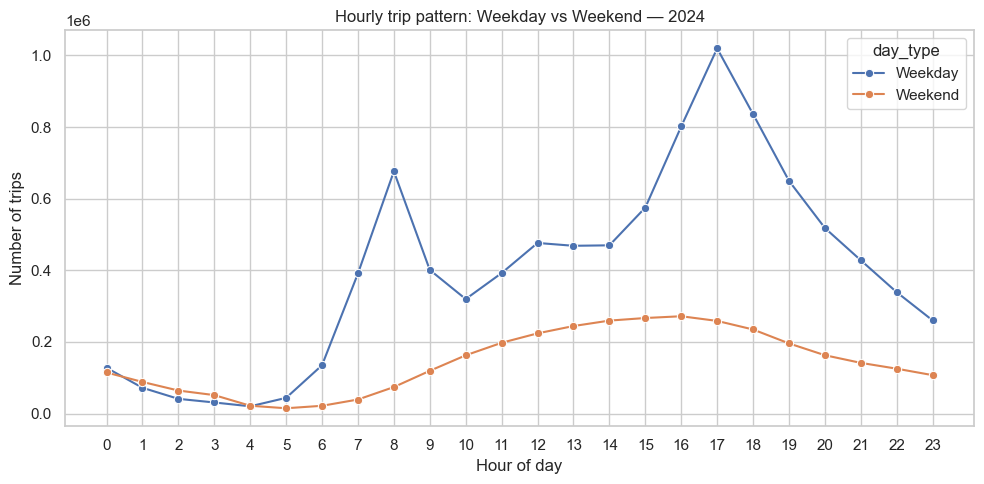

In [8]:
# Flag weekday vs weekend
trips["is_weekend"] = trips["day_of_week"].isin(["Saturday", "Sunday"])
trips["day_type"] = trips["is_weekend"].map({True: "Weekend", False: "Weekday"})

# Average trips per hour, normalized by number of days in each category
# (5 weekdays vs 2 weekend days per week, so we compare averages, not raw totals)
hourly_by_type = (
    trips.groupby(["day_type", "hour"])
    .size()
    .reset_index(name="trip_count")
)

fig, ax = plt.subplots()
sns.lineplot(data=hourly_by_type, x="hour", y="trip_count", hue="day_type", marker="o", ax=ax)
ax.set_title("Hourly trip pattern: Weekday vs Weekend — 2024")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of trips")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Station-level analysis

Which stations generate the most departures? This identifies the highest-priority
locations for rebalancing operations.

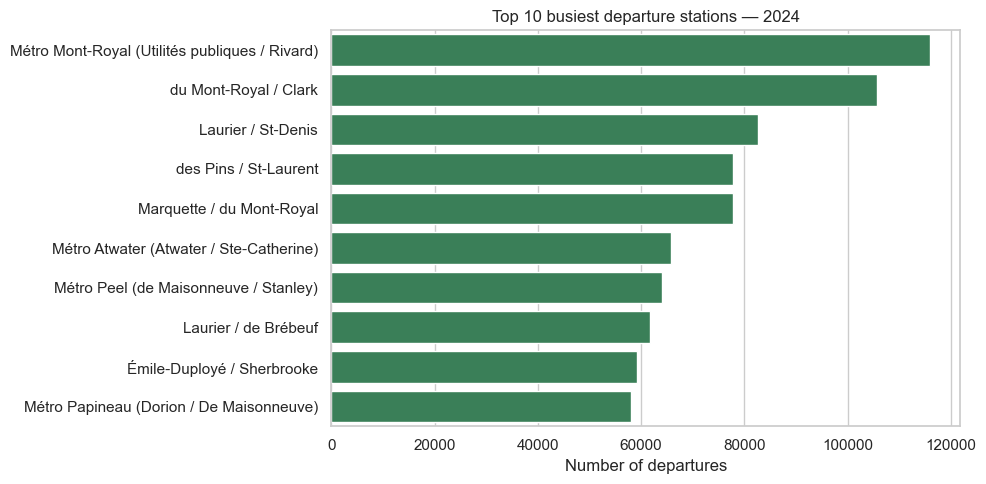

In [11]:
# Convert from category dtype to plain string to avoid carrying
# unused category levels into the plot
top_start_stations = (
    trips["STARTSTATIONNAME"]
    .value_counts()
    .head(10)
)
top_start_stations.index = top_start_stations.index.astype(str)

fig, ax = plt.subplots()
sns.barplot(y=top_start_stations.index, x=top_start_stations.values, color="seagreen", ax=ax)
ax.set_title("Top 10 busiest departure stations — 2024")
ax.set_xlabel("Number of departures")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Station imbalance: departures vs arrivals

A station is a rebalancing priority when departures and arrivals are structurally
different — for example, a residential station that empties every morning as commuters
leave, or a downtown station that fills up as workers arrive.

In [12]:
# Count departures and arrivals per station, then merge them side by side
departures = trips["STARTSTATIONNAME"].value_counts()
arrivals = trips["ENDSTATIONNAME"].value_counts()

station_balance = pd.DataFrame({
    "departures": departures,
    "arrivals": arrivals
}).fillna(0)

# Net balance: positive means the station loses more bikes than it gains (needs restocking)
station_balance["net_balance"] = station_balance["arrivals"] - station_balance["departures"]

# Only keep stations with meaningful volume to avoid noise from rarely-used stations
station_balance = station_balance[station_balance["departures"] + station_balance["arrivals"] > 1000]

station_balance.sort_values("net_balance").head(10)

,departures,arrivals,net_balance
Berri / Cherrier,52108.0,31913.0,-20195.0
Métro Sherbrooke (de Rigaud / Berri),56629.0,39412.0,-17217.0
Parc Jeanne-Mance (monument sir George-Étienne-Cartier),46890.0,31743.0,-15147.0
Laurier / St-Denis,82745.0,70215.0,-12530.0
Parc Jeanne-Mance (du Mont-Royal / du Parc),45330.0,32854.0,-12476.0
du Mont-Royal / Clark,105807.0,93804.0,-12003.0
Marmier / St-Denis,36513.0,25090.0,-11423.0
Duluth / de l'Esplanade,40955.0,31202.0,-9753.0
Ste-Catherine / St-Mathieu,38720.0,30062.0,-8658.0
Clark / Prince-Arthur,53026.0,44385.0,-8641.0


station_balance.sort_values("net_balance", ascending=False).head(10)

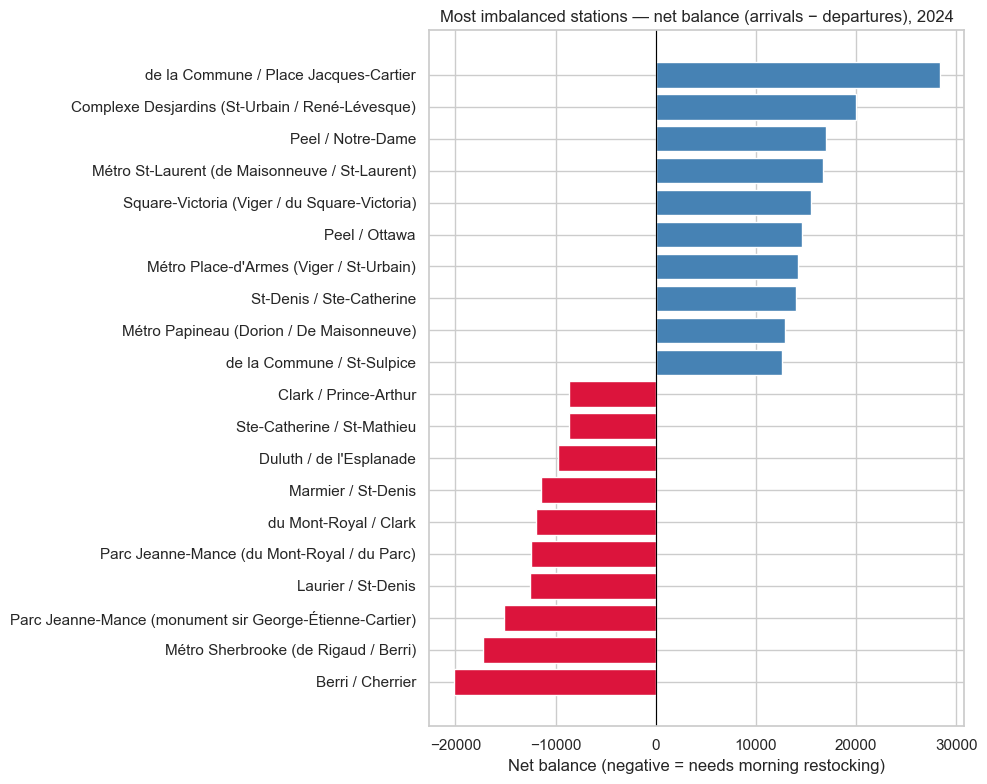

In [14]:
# Combine top 10 "exporters" and top 10 "importers" into one chart
top_exporters = station_balance.sort_values("net_balance").head(10)
top_importers = station_balance.sort_values("net_balance", ascending=False).head(10)

imbalance_extremes = pd.concat([top_exporters, top_importers]).sort_values("net_balance")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["crimson" if v < 0 else "steelblue" for v in imbalance_extremes["net_balance"]]
ax.barh(imbalance_extremes.index, imbalance_extremes["net_balance"], color=colors)
ax.set_title("Most imbalanced stations — net balance (arrivals − departures), 2024")
ax.set_xlabel("Net balance (negative = needs morning restocking)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Geographic view of station imbalance

Plotting net balance on a map makes the spatial pattern immediately visible —
confirming the shift from residential (Plateau) to commercial/tourist areas
(Downtown, Old Port).

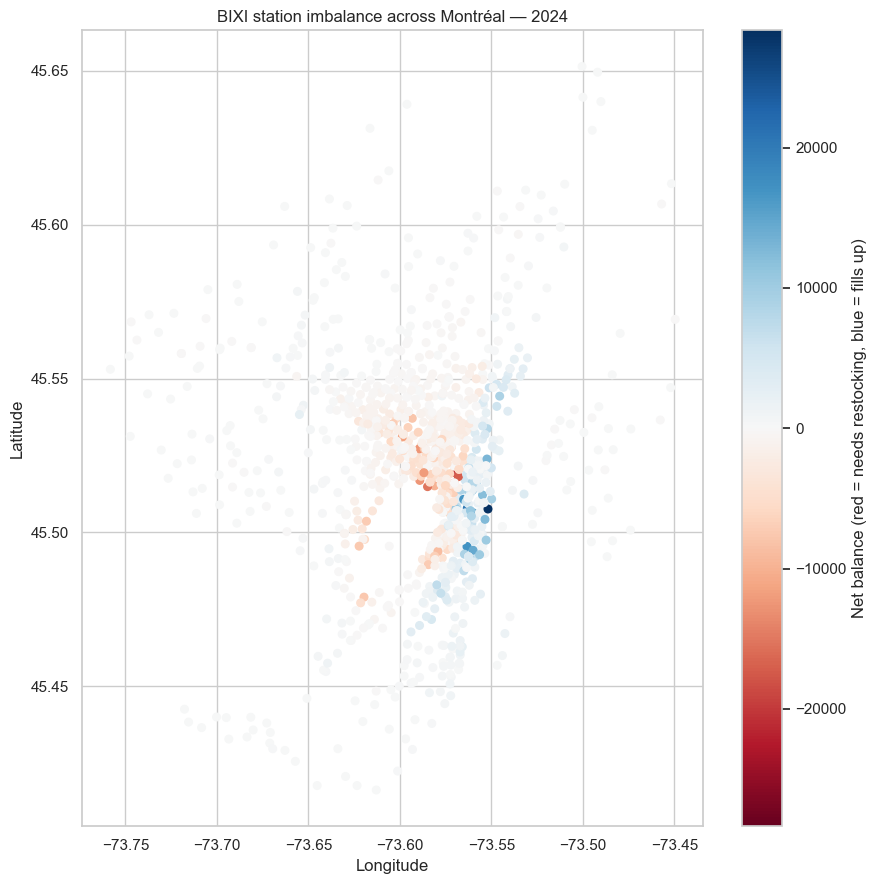

In [16]:
# Get station coordinates (one row per station — using the first occurrence)
station_coords = (
    trips.groupby("STARTSTATIONNAME", observed=True)[["STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE"]]
    .first()
)
station_coords.index = station_coords.index.astype(str)

# Merge with the balance table computed earlier
map_data = station_balance.join(station_coords)

fig, ax = plt.subplots(figsize=(9, 9))
scatter = ax.scatter(
    map_data["STARTSTATIONLONGITUDE"],
    map_data["STARTSTATIONLATITUDE"],
    c=map_data["net_balance"],
    cmap="RdBu",
    s=30,
    vmin=-map_data["net_balance"].abs().max(),
    vmax=map_data["net_balance"].abs().max(),
)
plt.colorbar(scatter, label="Net balance (red = needs restocking, blue = fills up)")
ax.set_title("BIXI station imbalance across Montréal — 2024")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Summary of findings

- **Temporal pattern**: clear commuter behavior on weekdays (peaks at 8am and 5pm),
  contrasted with a smooth, leisure-driven curve on weekends peaking in the afternoon.
- **Station activity**: usage is concentrated in the Plateau-Mont-Royal and Downtown
  areas; the busiest station (Métro Mont-Royal) sees over 115,000 departures/year.
- **Imbalance pattern**: residential stations in the Plateau consistently lose bikes
  (e.g., Berri / Cherrier: -20,195 net), while Downtown and Old Port stations
  consistently gain them (e.g., de la Commune / Place Jacques-Cartier: +28,361 net).
  This points to a clear rebalancing direction: bikes need to be moved from
  Downtown/Old Port back to the Plateau overnight to meet morning demand.

**Next steps**: model this data in SQL to formalize these queries, then build the
Power BI dashboard for interactive exploration.